# EfficientNet-B1 CNN Training for LULC Classification

This notebook trains an EfficientNet-B1 CNN model on satellite imagery for Land Use/Land Cover classification.
The trained model is saved to `../models/cnn_final.pth` for use in the Streamlit web application.

## Training Strategy:
- **Architecture**: EfficientNet-B1 with transfer learning (ImageNet weights)
- **Input Size**: 128x128 pixels
- **Two-Phase Training**: Freeze backbone initially, then fine-tune all layers
- **Augmentation**: Strong (rotation, affine, color jitter, erasing)
- **Class Balance**: WeightedRandomSampler + weighted loss
- **Learning Rate**: Warmup + Cosine Annealing
- **Early Stopping**: Patience=12 epochs

## Step 1: Setup Working Directory

In [1]:
import os
from pathlib import Path

# Navigate to project root
current_dir = Path.cwd()
if (current_dir / "notebooks").exists() and (current_dir / "data").exists():
    print(f"✓ Working directory: {current_dir}")
elif (current_dir.parent / "data").exists():
    os.chdir(current_dir.parent)
    print(f"✓ Changed to project root: {Path.cwd()}")
else:
    for parent in current_dir.parents:
        if (parent / "notebooks").exists() and (parent / "data").exists() and (parent / "src").exists():
            os.chdir(parent)
            print(f"✓ Found and moved to project root: {Path.cwd()}")
            break

## Step 2: Imports & Setup

In [2]:
import sys
from pathlib import Path
from collections import Counter
import shutil

import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader, Subset, WeightedRandomSampler
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR
from tqdm import tqdm
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Project root is set to cwd
PROJECT_ROOT = Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

# Setup device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version: {torch.version.cuda}")
    print(f"PyTorch Version: {torch.__version__}")

Device: cuda
GPU: Tesla T4
CUDA Version: 12.8
PyTorch Version: 2.10.0+cu128


## Step 3: Paths & Configuration

In [3]:
DATA_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
REPORT_DIR = PROJECT_ROOT / "report"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

# Configuration
IMG_SIZE = 128
if device.type == "cpu":
    NUM_EPOCHS = 15
    BATCH_SIZE = 32
    print("⚠ Running on CPU - reduced epochs and batch size")
else:
    NUM_EPOCHS = 50
    BATCH_SIZE = 128
    print("✓ Running on GPU - full training schedule")

FREEZE_EPOCHS = 3
EARLY_STOP_PATIENCE = 12

print(f"\nConfiguration:")
print(f"  Image Size: {IMG_SIZE}x{IMG_SIZE}")
print(f"  Batch Size: {BATCH_SIZE}")
print(f"  Epochs: {NUM_EPOCHS}")
print(f"  Freeze Epochs: {FREEZE_EPOCHS}")
print(f"\nDirectories:")
print(f"  Data: {DATA_DIR}")
print(f"  Models: {MODELS_DIR}")
print(f"  Report: {REPORT_DIR}")

✓ Running on GPU - full training schedule

Configuration:
  Image Size: 128x128
  Batch Size: 128
  Epochs: 50
  Freeze Epochs: 3

Directories:
  Data: /content/data/processed
  Models: /content/models
  Report: /content/report


## Step 4: Prepare Dataset

In [4]:
# Find classes with data
all_classes = sorted([d.name for d in DATA_DIR.iterdir() if d.is_dir()])
classes_with_data = [cls for cls in all_classes if any((DATA_DIR / cls).glob("*.jpg"))]

print(f"All classes: {all_classes}")
print(f"Classes with data: {classes_with_data}")

if not classes_with_data:
    raise FileNotFoundError(f"No classes with data found in {DATA_DIR}")

# Create temporary dataset directory with only classes that have images
temp_dataset_dir = PROJECT_ROOT / "data" / "temp_dataset"
if temp_dataset_dir.exists():
    shutil.rmtree(temp_dataset_dir)
temp_dataset_dir.mkdir(parents=True, exist_ok=True)

print(f"\nPreparing dataset...")
total_images = 0
for cls in classes_with_data:
    (temp_dataset_dir / cls).mkdir(exist_ok=True)
    src_dir = DATA_DIR / cls
    img_files = list(src_dir.glob("*.jpg"))
    
    for img in tqdm(img_files, desc=f"  {cls}", leave=False):
        target = temp_dataset_dir / cls / img.name
        if not target.exists():
            shutil.copy2(str(img), str(target))
            total_images += 1
    
    print(f"  {cls}: {len(img_files)} images")

print(f"\nDataset ready: {temp_dataset_dir}")
print(f"Total images: {total_images}")

All classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Classes with data: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']

Preparing dataset...


  AnnualCrop: 3000 images


  Forest: 3000 images


  HerbaceousVegetation: 3000 images


  Highway: 2500 images


...

  Pasture: 2000 images


  PermanentCrop: 2500 images


  Residential: 3000 images


  River: 2500 images


  SeaLake: 3000 images

Dataset ready: /content/data/temp_dataset
Total images: 27000


## Step 5: Data Augmentation & Loading

In [5]:
# Augmentation pipelines
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(45),
    transforms.RandomAffine(degrees=0, translate=(0.15, 0.15), scale=(0.85, 1.15)),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.3, hue=0.1),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.2)),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Load dataset
full_dataset = datasets.ImageFolder(str(temp_dataset_dir), transform=None)
class_names = full_dataset.classes
num_classes = len(class_names)

print(f"Dataset Info:")
print(f"  Classes: {class_names}")
print(f"  Num Classes: {num_classes}")
print(f"  Total images: {len(full_dataset)}")

# Train-Val-Test split
total = len(full_dataset)
train_size = int(0.7 * total)
val_size = int(0.15 * total)
test_size = total - train_size - val_size

gen = torch.Generator().manual_seed(42)
train_subset, val_subset, test_subset = torch.utils.data.random_split(
    full_dataset, [train_size, val_size, test_size], generator=gen
)

print(f"\nData Split:")
print(f"  Train: {train_size} ({train_size/total*100:.1f}%)")
print(f"  Val: {val_size} ({val_size/total*100:.1f}%)")
print(f"  Test: {test_size} ({test_size/total*100:.1f}%)")

Dataset Info:
  Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
  Num Classes: 10
  Total images: 27000

Data Split:
  Train: 18900 (70.0%)
  Val: 4050 (15.0%)
  Test: 4050 (15.0%)


## Step 6: Class Balancing

In [6]:
# Get class distribution in training set
train_labels = [full_dataset.targets[i] for i in train_subset.indices]
class_counts = Counter(train_labels)
print(f"Train class distribution: {dict(sorted(class_counts.items()))}")

# Weighted sampler for class balance
weight_per_class = {c: 1.0 / count for c, count in class_counts.items()}
sample_weights = [weight_per_class[label] for label in train_labels]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True,
    generator=torch.Generator().manual_seed(42),
)

# Class-weighted loss
class_weight_tensor = torch.tensor(
    [1.0 / class_counts.get(i, 1) for i in range(num_classes)], 
    dtype=torch.float32
)
class_weight_tensor = class_weight_tensor / class_weight_tensor.sum() * num_classes
class_weight_tensor = class_weight_tensor.to(device)

print(f"Class weights (for loss): {class_weight_tensor.cpu().numpy()}")

Train class distribution: {0: 2062, 1: 2127, 2: 2097, 3: 1728, 4: 1770, 5: 1392, 6: 1733, 7: 2096, 8: 1743, 9: 2152}
Class weights (for loss): [0.900321   0.8728076  0.8852942  1.0743414  1.0488485  1.3336651
 1.0712416  0.88571656 1.0650958  0.86266816]


## Step 7: Create Data Loaders

In [7]:
class _TransformSubset(torch.utils.data.Dataset):
    """Apply transforms to subset"""
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        img, label = self.subset[idx]
        if self.transform:
            img = self.transform(img)
        return img, label

# Create datasets with transforms
train_dataset = _TransformSubset(train_subset, train_transform)
val_dataset = _TransformSubset(val_subset, eval_transform)
test_dataset = _TransformSubset(test_subset, eval_transform)

# Create loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Data Loaders:")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")
print(f"  Test batches: {len(test_loader)}")

Data Loaders:
  Train batches: 148
  Val batches: 32
  Test batches: 32


## Step 8: Build Model

In [8]:
print("Loading EfficientNet-B1 with ImageNet weights...")
model = models.efficientnet_b1(weights=models.EfficientNet_B1_Weights.DEFAULT)
model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, num_classes)
model = model.to(device)

print(f"\nModel: EfficientNet-B1")
print(f"Output classes: {num_classes}")
print(f"Device: {device}")

# Initial freeze: only train classifier head
for param in model.parameters():
    param.requires_grad = False
for param in model.classifier.parameters():
    param.requires_grad = True

print(f"\nPhase 1: Backbone frozen - only training classifier head")

Loading EfficientNet-B1 with ImageNet weights...
Downloading: "https://download.pytorch.org/models/efficientnet_b1-c27df63c.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b1-c27df63c.pth


100%|██████████| 30.1M/30.1M [00:00<00:00, 36.3MB/s]



Model: EfficientNet-B1
Output classes: 10
Device: cuda

Phase 1: Backbone frozen - only training classifier head


## Step 9: Training Setup

In [9]:
criterion = nn.CrossEntropyLoss(weight=class_weight_tensor)
optimizer = optim.AdamW(model.classifier.parameters(), lr=5e-3, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-7)

best_val_acc = 0.0
patience_counter = 0
model_path = MODELS_DIR / "cnn_final.pth"

training_history = {
    'epoch': [],
    'train_loss': [],
    'train_acc': [],
    'val_acc': [],
    'lr': []
}

print(f"Optimizer: AdamW (lr=5e-3, weight_decay=1e-4)")
print(f"Scheduler: Cosine Annealing")
print(f"Loss: CrossEntropyLoss (with class weights)")

Optimizer: AdamW (lr=5e-3, weight_decay=1e-4)
Scheduler: Cosine Annealing
Loss: CrossEntropyLoss (with class weights)


## Step 10: Train Model

In [10]:
print("\n" + "="*70)
print(f"Training EfficientNet-B1 for {NUM_EPOCHS} epochs")
print("="*70 + "\n")

for epoch in range(NUM_EPOCHS):
    # Unfreeze backbone after FREEZE_EPOCHS
    if epoch == FREEZE_EPOCHS:
        print(f"\n>>> Unfreezing backbone at epoch {epoch + 1}")
        for param in model.parameters():
            param.requires_grad = True
        optimizer = optim.AdamW([
            {"params": model.classifier.parameters(), "lr": 2e-3},
            {"params": (p for n, p in model.named_parameters()
                        if "classifier" not in n and p.requires_grad), "lr": 1e-4},
        ], weight_decay=1e-4)
        scheduler = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS - FREEZE_EPOCHS, eta_min=1e-7)
    
    # Training phase
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [TRAIN]")
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs.data, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()
        
        pbar.set_postfix({'loss': f"{loss.item():.4f}"})
    
    train_loss = train_loss / train_total
    train_acc = train_correct / train_total
    
    # Validation phase
    model.eval()
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
    
    val_acc = val_correct / val_total
    
    # Scheduler step
    scheduler.step()
    lr_now = optimizer.param_groups[0]["lr"]
    
    # Log history
    training_history['epoch'].append(epoch + 1)
    training_history['train_loss'].append(train_loss)
    training_history['train_acc'].append(train_acc)
    training_history['val_acc'].append(val_acc)
    training_history['lr'].append(lr_now)
    
    # Print progress
    print(f"Epoch {epoch+1:2d} | Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | LR: {lr_now:.2e}")
    
    # Early stopping
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        torch.save(model.state_dict(), model_path)
        print(f"            >>> Best model saved (val_acc={best_val_acc:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= EARLY_STOP_PATIENCE:
            print(f"\nEarly stopping at epoch {epoch + 1} (no improvement for {EARLY_STOP_PATIENCE} epochs)")
            break

print("\n" + "="*70)
print("Training Complete!")
print("="*70)


Training EfficientNet-B1 for 50 epochs



Epoch 1/50 [TRAIN]: 100%|██████████| 148/148 [01:45<00:00,  1.40it/s, loss=0.7432]


Epoch  1 | Loss: 0.9692 | Train Acc: 0.7037 | Val Acc: 0.7827 | LR: 5.00e-03
            >>> Best model saved (val_acc=0.7827)


Epoch 2/50 [TRAIN]: 100%|██████████| 148/148 [01:43<00:00,  1.43it/s, loss=0.5837]


Epoch  2 | Loss: 0.7280 | Train Acc: 0.7600 | Val Acc: 0.8037 | LR: 4.98e-03
            >>> Best model saved (val_acc=0.8037)


...

Epoch 47 | Loss: 0.0486 | Train Acc: 0.9825 | Val Acc: 0.9793 | LR: 2.01e-05


Epoch 48/50 [TRAIN]: 100%|██████████| 148/148 [02:11<00:00,  1.12it/s, loss=0.1115]


Epoch 48 | Loss: 0.0560 | Train Acc: 0.9806 | Val Acc: 0.9793 | LR: 9.02e-06


Epoch 49/50 [TRAIN]: 100%|██████████| 148/148 [02:13<00:00,  1.11it/s, loss=0.0468]


Epoch 49 | Loss: 0.0578 | Train Acc: 0.9803 | Val Acc: 0.9780 | LR: 2.33e-06

Early stopping at epoch 49 (no improvement for 12 epochs)

Training Complete!


## Step 11: Plot Training History

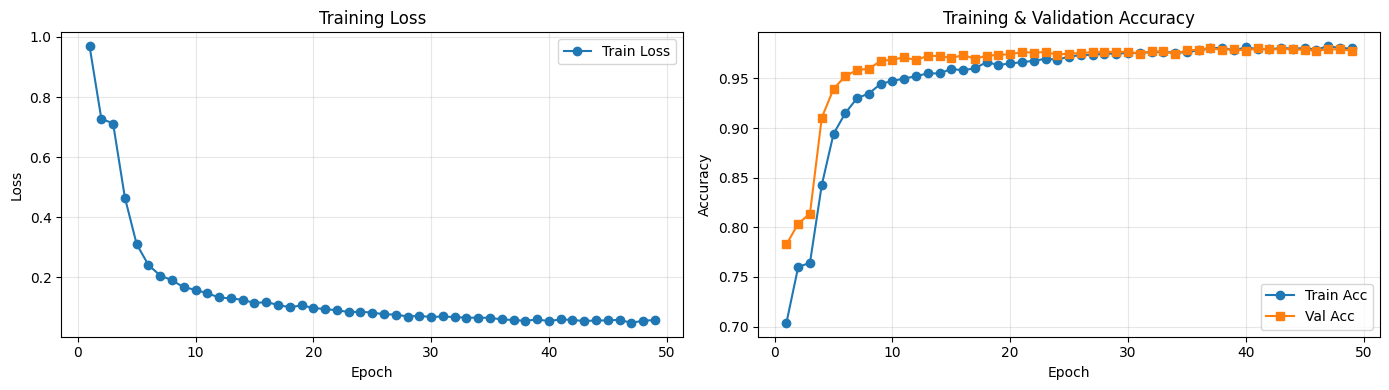

Saved training history plot


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Loss
axes[0].plot(training_history['epoch'], training_history['train_loss'], marker='o', label='Train Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Accuracy
axes[1].plot(training_history['epoch'], training_history['train_acc'], marker='o', label='Train Acc')
axes[1].plot(training_history['epoch'], training_history['val_acc'], marker='s', label='Val Acc')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training & Validation Accuracy')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.savefig(REPORT_DIR / 'cnn_training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved training history plot")

## Step 12: Evaluate on Test Set

In [12]:
print("\nLoading best model and evaluating on test set...")
model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
model.eval()

all_preds = []
all_labels = []
with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Evaluating"):
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

test_acc = accuracy_score(all_labels, all_preds)
print(f"\nTest Accuracy: {test_acc * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))


Loading best model and evaluating on test set...


Evaluating: 100%|██████████| 32/32 [00:06<00:00,  4.81it/s]


Test Accuracy: 97.58%

Classification Report:
                      precision    recall  f1-score   support

          AnnualCrop       0.97      0.97      0.97       472
              Forest       0.96      1.00      0.98       442
HerbaceousVegetation       0.98      0.95      0.96       458
             Highway       0.97      0.99      0.98       391
          Industrial       0.99      0.98      0.99       378
             Pasture       0.98      0.95      0.96       299
       PermanentCrop       0.94      0.97      0.95       379
         Residential       0.98      1.00      0.99       450
               River       0.98      0.98      0.98       375
             SeaLake       0.99      0.98      0.99       406

            accuracy                           0.98      4050
           macro avg       0.98      0.98      0.98      4050
        weighted avg       0.98      0.98      0.98      4050



## Step 13: Confusion Matrix

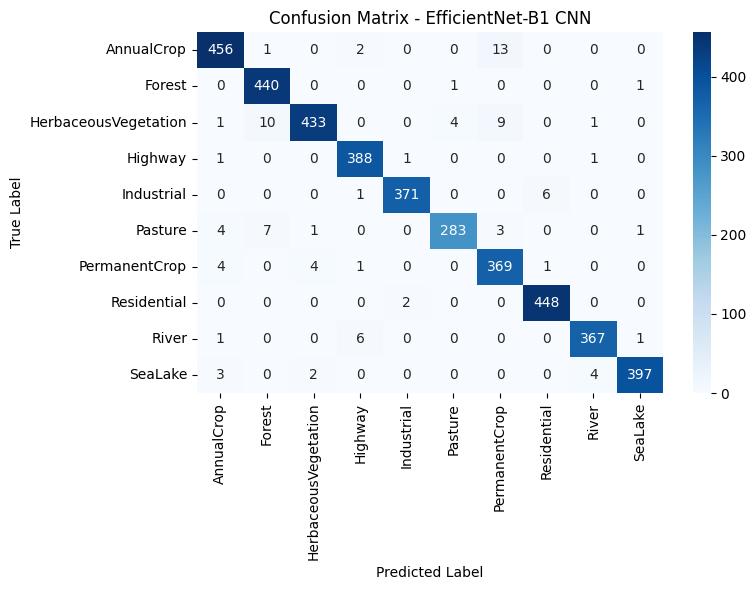

Saved confusion matrix plot


In [13]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - EfficientNet-B1 CNN')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig(REPORT_DIR / 'cnn_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved confusion matrix plot")

## Step 14: Save Model

In [14]:
print(f"\n" + "="*70)
print("✓ Model Saved Successfully!")
print("="*70)
print(f"\nCNN Model Path: {model_path}")
print(f"  File size: {model_path.stat().st_size / 1024 / 1024:.2f} MB")
print(f"  Architecture: EfficientNet-B1")
print(f"  Input: 128x128")
print(f"  Output: {num_classes} classes")
print(f"  Classes: {class_names}")
print(f"  Test Accuracy: {test_acc * 100:.2f}%")
print(f"\n✓ Ready for Streamlit app: models/cnn_final.pth")


✓ Model Saved Successfully!

CNN Model Path: /content/models/cnn_final.pth
  File size: 25.31 MB
  Architecture: EfficientNet-B1
  Input: 128x128
  Output: 10 classes
  Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
  Test Accuracy: 97.58%

✓ Ready for Streamlit app: models/cnn_final.pth


## Step 15: Cleanup

In [15]:
# Remove temporary dataset
if temp_dataset_dir.exists():
    shutil.rmtree(temp_dataset_dir)
    print(f"Cleaned up: {temp_dataset_dir}")

print("\n✓ All done! Models ready for Streamlit web app.")

Cleaned up: /content/data/temp_dataset

✓ All done! Models ready for Streamlit web app.
